# DCGAN — Complete CASIA Faculty Demo

Loads the trained generator/discriminator, plots adversarial losses and epoch progression, reports FID/IS, and produces fresh synthetic samples. No retraining.

In [1]:
from pathlib import Path
import json, random, sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from IPython.display import display
SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
candidates=[Path.cwd(),*Path.cwd().parents,Path('/content/Digital-Evidence-GenAI'),Path('/content/AI-Digital-Evidence-Intelligence-Platform')]
PROJECT_ROOT=next((p.resolve() for p in candidates if (p/'src').is_dir() and (p/'checkpoints').is_dir()),None)
if PROJECT_ROOT is None: raise FileNotFoundError('Run inside the project repository.')
sys.path.insert(0,str(PROJECT_ROOT/'src'))
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Project:',PROJECT_ROOT)
print('Device:',torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')
print('LOAD-ONLY DEMO: models will not be retrained.')

Project: C:\Users\Chetanraje\Desktop\GAA\Digital_Evidence
Device: CPU
LOAD-ONLY DEMO: models will not be retrained.


## 1. Dataset and preprocessing

RGB 64×64, normalized to `[-1,1]`; unconditional training without class labels.

In [2]:
frames={name:pd.read_csv(PROJECT_ROOT/'data'/'splits'/f'{name}.csv') for name in ('train','validation','test')}
rows=[]
for name,frame in frames.items(): rows.append({'split':name.title(),'total':len(frame),'authentic':int((frame.label==0).sum()),'tampered':int((frame.label==1).sum())})
display(pd.DataFrame(rows)); print('Total:',sum(r['total'] for r in rows),'| seed: 42')
print('Masks are excluded; labels are metadata, not reconstruction targets.')

,split,total,authentic,tampered
0,Train,8830,5244,3586
1,Validation,1892,1124,768
2,Test,1892,1123,769


Total: 12614 | seed: 42
Masks are excluded; labels are metadata, not reconstruction targets.


## 2. Architecture and checkpoints

Generator: `100×1×1 → 512×4×4 → 256×8×8 → 128×16×16 → 64×32×32 → 3×64×64`. Discriminator reverses the progression and returns logits.

In [3]:
from gan_inference import GANInference
G=PROJECT_ROOT/'checkpoints'/'best_generator.pth'; D=PROJECT_ROOT/'checkpoints'/'best_discriminator.pth'; gan=GANInference(G,D,DEVICE,100)
print('Generator:',G,'| Parameters:',f'{sum(p.numel() for p in gan.generator.parameters()):,}'); print('Discriminator:',D,'| Parameters:',f'{sum(p.numel() for p in gan.discriminator.parameters()):,}'); print('Latent dimension: 100')

Generator: C:\Users\Chetanraje\Desktop\GAA\Digital_Evidence\checkpoints\best_generator.pth | Parameters: 3,576,704
Discriminator: C:\Users\Chetanraje\Desktop\GAA\Digital_Evidence\checkpoints\best_discriminator.pth | Parameters: 2,765,568
Latent dimension: 100


## 3. Training configuration

30 epochs; batch 64; Adam 0.0002; betas `(0.5,0.999)`; BCEWithLogitsLoss; DCGAN initialization; fixed noise for progress.

## 4. Adversarial training losses

G and D losses have different objectives and must not be compared as if they were the same score.

,epoch,generator_loss,discriminator_loss,epoch_time_seconds
25,26,3.253857,0.332754,22.066688
26,27,3.296120,0.266905,21.448974
27,28,3.288084,0.284296,21.541642
28,29,3.310782,0.370273,22.011581
29,30,3.374140,0.274793,22.055472


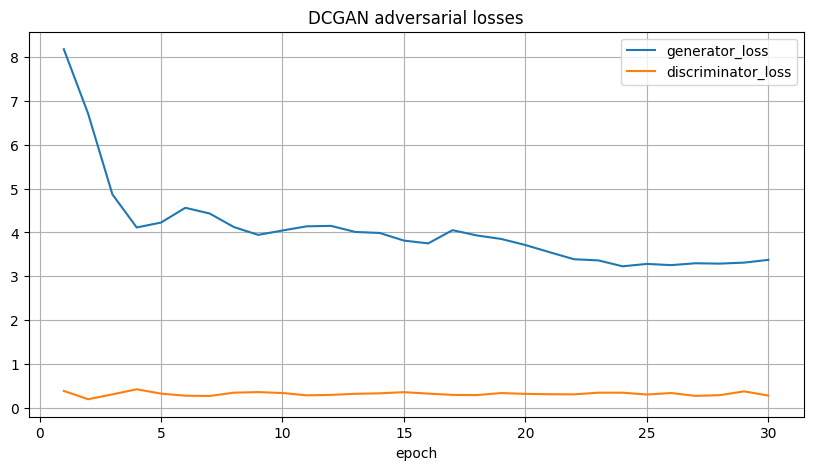

Epochs: 30 | Final G/D: 3.3741403796376974 0.2747926720193703 | Time: 670.718453149 s


In [4]:
history=pd.read_csv(PROJECT_ROOT/'results'/'gan_training_history.csv'); display(history.tail()); history.plot(x='epoch',y=['generator_loss','discriminator_loss'],figsize=(10,5),grid=True,title='DCGAN adversarial losses'); plt.show(); print('Epochs:',len(history),'| Final G/D:',history.generator_loss.iloc[-1],history.discriminator_loss.iloc[-1],'| Time:',history.epoch_time_seconds.sum(),'s')

## 5. Generated progress every five epochs

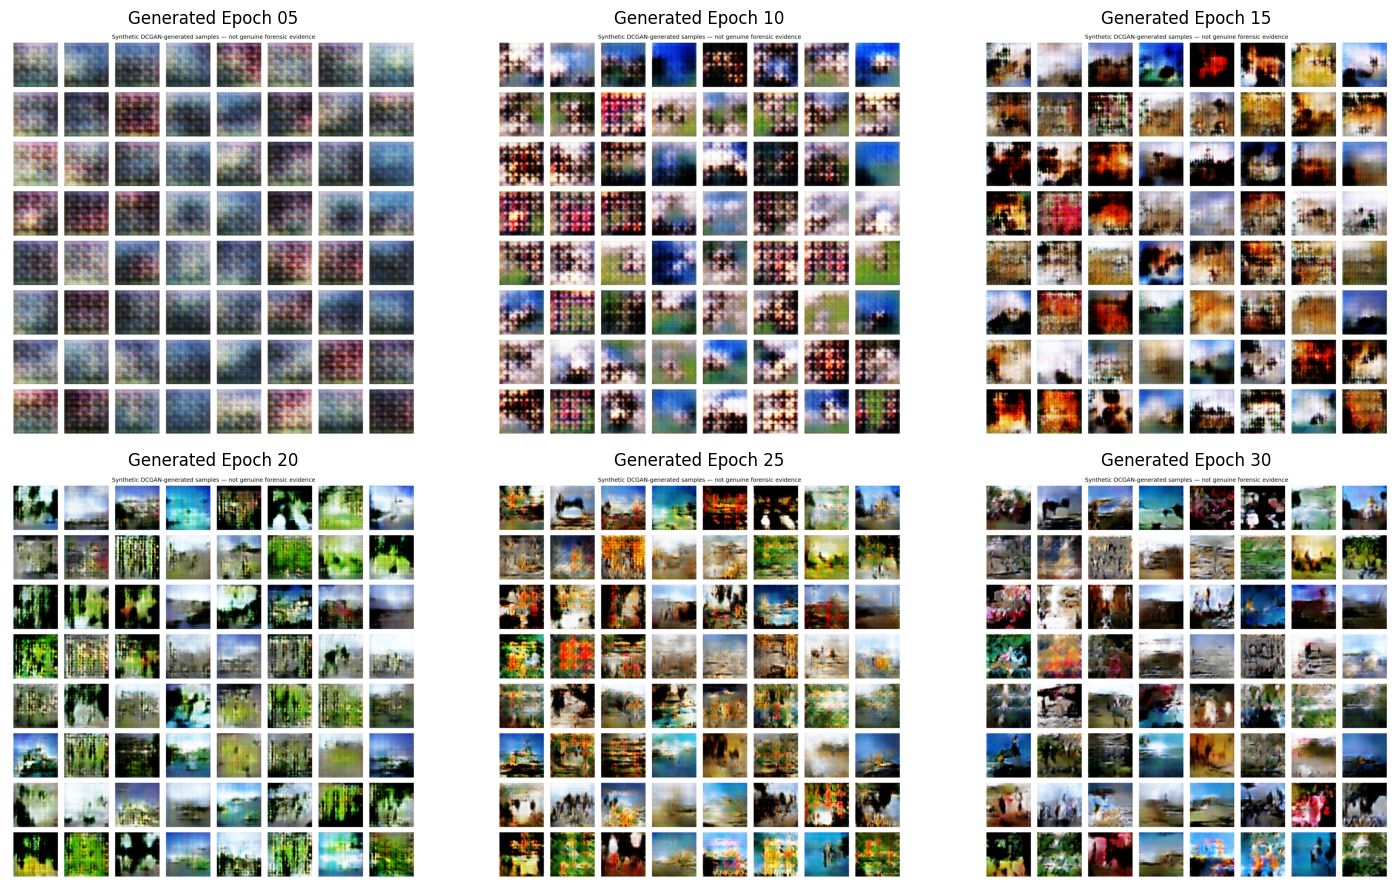

In [5]:
paths=[PROJECT_ROOT/'outputs'/'gan'/f'generated_epoch_{e:02d}.png' for e in (5,10,15,20,25,30)]; fig,axes=plt.subplots(2,3,figsize=(15,9))
for ax,path in zip(axes.flat,paths):
 if path.is_file(): ax.imshow(Image.open(path)); ax.set_title(path.stem.replace('_',' ').title())
 ax.axis('off')
plt.tight_layout(); plt.show()

## 6. Fresh synthetic generation

Synthetic research outputs—not genuine forensic evidence.

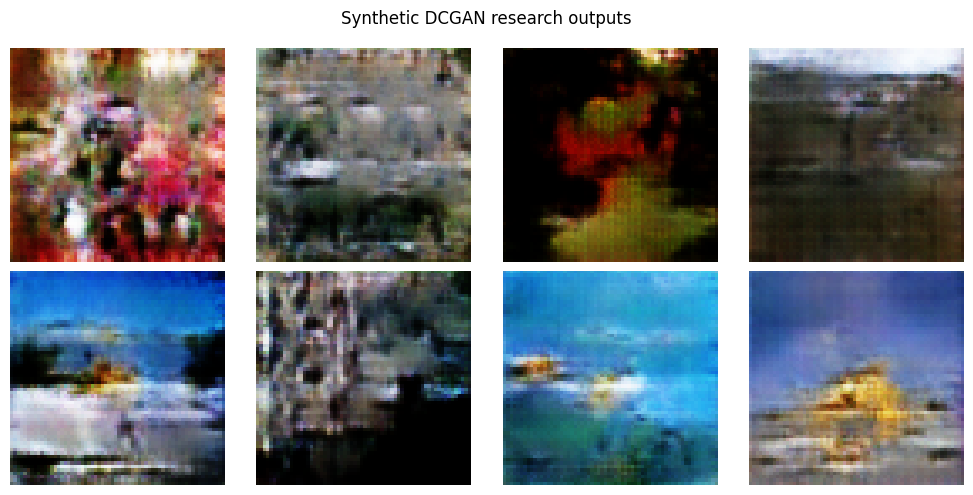

In [6]:
samples=gan.generate(8); fig,axes=plt.subplots(2,4,figsize=(10,5))
for ax,img in zip(axes.flat,samples): ax.imshow(img); ax.axis('off')
plt.suptitle('Synthetic DCGAN research outputs'); plt.tight_layout(); plt.show()

## 7. FID and Inception Score

In [7]:
metrics=json.loads((PROJECT_ROOT/'results'/'gan_test_metrics.json').read_text()); display(pd.DataFrame([metrics]).T.rename(columns={0:'value'})); print('Lower FID is generally better. IS uses ImageNet features and is not domain-specific forensic validation.')

,value
real_images,1892
generated_images,1892
fid,169.878586
fid_features,2048
inception_score_mean,2.949508
inception_score_std,0.131627
inception_score_splits,10
evaluation_time_seconds,33.143685
warning,None


Lower FID is generally better. IS uses ImageNet features and is not domain-specific forensic validation.


## 8. Final saved grid

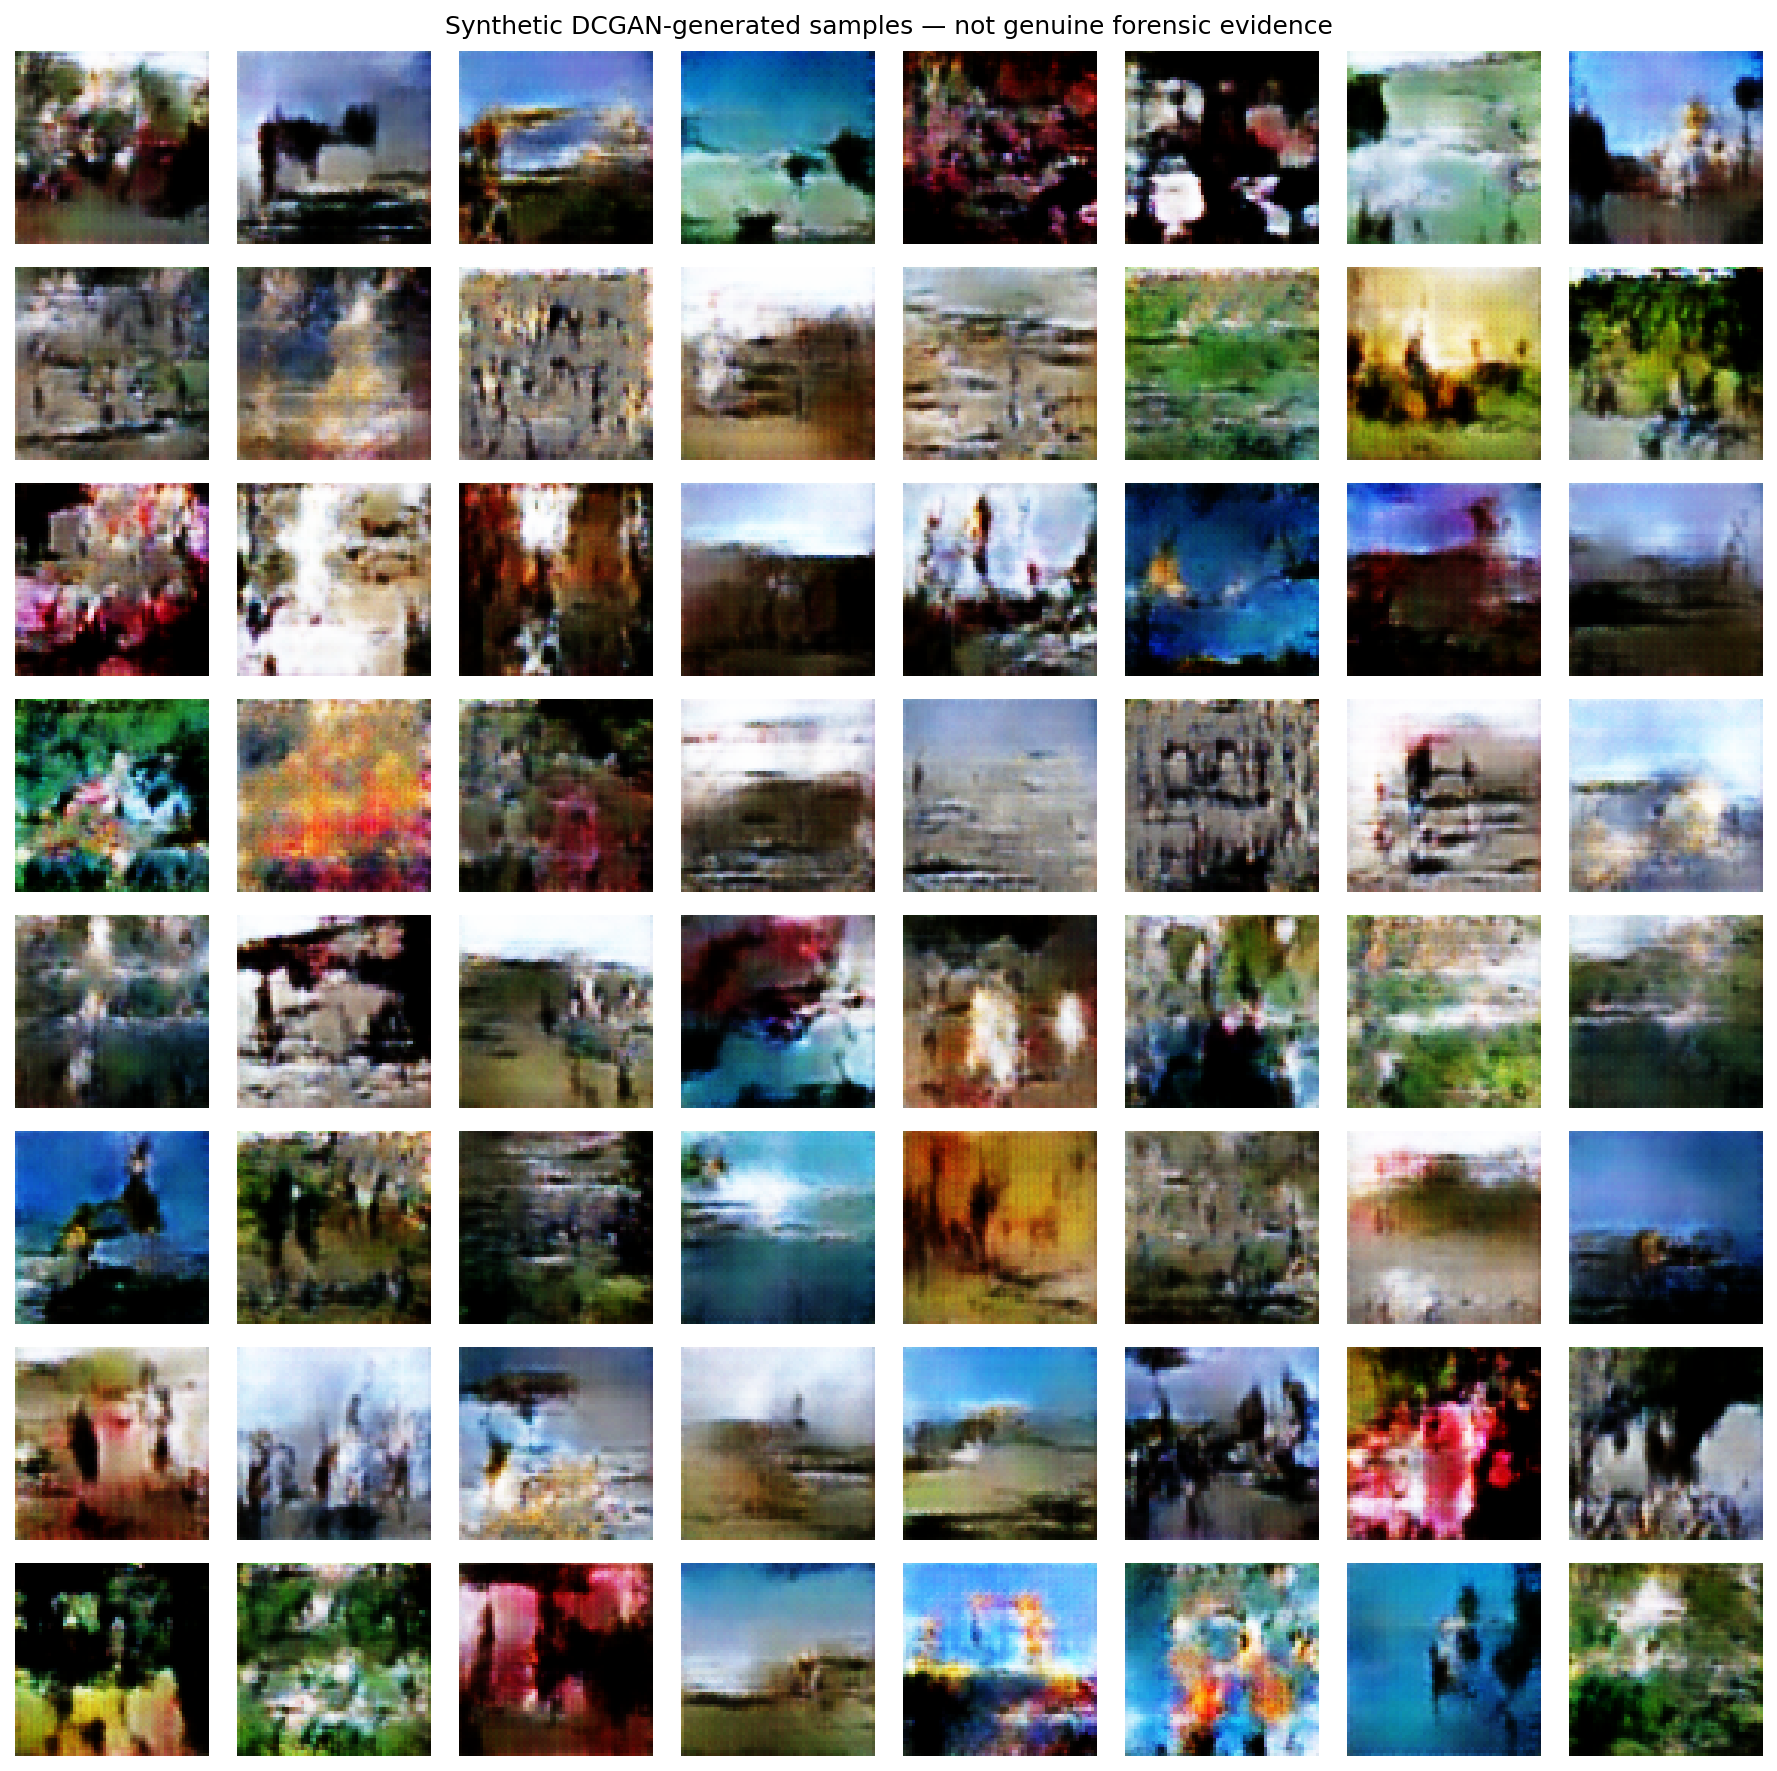

In [8]:
path=PROJECT_ROOT/'outputs'/'gan'/'final_generated_samples.png'
if path.is_file(): display(Image.open(path))

## Conclusion

DCGAN is the dedicated synthetic-generation module. Its outputs remain experimental and FID/IS do not establish forensic usefulness.